# Dados


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal as mv_norm

from utils.data import generate_data
from utils.plot import plot_2D, plot_features

# Funções auxiliares


In [2]:
def get_proba(data, **kwargs):
    means = kwargs["means"]
    covs = kwargs["covs"]
    priors = kwargs["priors"]
    n_classes = kwargs["n_classes"]

    prob = np.zeros((data.shape[0], n_classes))
    for i in range(n_classes):
        prob[:, i] = mv_norm(means[i], covs[i]).pdf(data)
        prob[:, i] *= priors[i]

    prob /= np.sum(prob, axis=1, keepdims=True)

    return prob

In [3]:
def classifier(prob, **kwargs):
    confidence = np.max(prob, axis=1)
    pred = np.argmax(prob, axis=1)
    return pred, confidence


def rejector(confidence, threshold=None):
    index = np.argsort(confidence)[::-1]
    if threshold is None:
        return index
    accepted_indices = index[confidence[index] >= threshold]
    return accepted_indices

In [ ]:
def balanced_error(y, y_pred):
    classes = np.unique(y)
    class_errors = []
    for cls in classes:
        cls_mask = y == cls
        cls_error = np.mean(y_pred[cls_mask] != cls)
        class_errors.append(cls_error)
    return np.mean(class_errors)


def worst_group_error(y, y_pred):
    unique_groups = np.unique(y)
    group_errors = []
    for group in unique_groups:
        group_mask = y == group
        group_error = np.mean(y_pred[group_mask] != group)
        group_errors.append(group_error)
    return np.max(group_errors)

In [5]:
def class_errors(y, y_pred):
    classes = np.unique(y)
    mask = y[:, None] == classes[None, :]
    error_vector = mask & (y_pred[:, None] != classes)
    return np.sum(error_vector, axis=0) / np.sum(mask, axis=0)


def balanced_error_vect(y, y_pred):
    return np.mean(class_errors(y, y_pred))


def worst_group_error_vect(y, y_pred):
    return np.max(class_errors(y, y_pred))

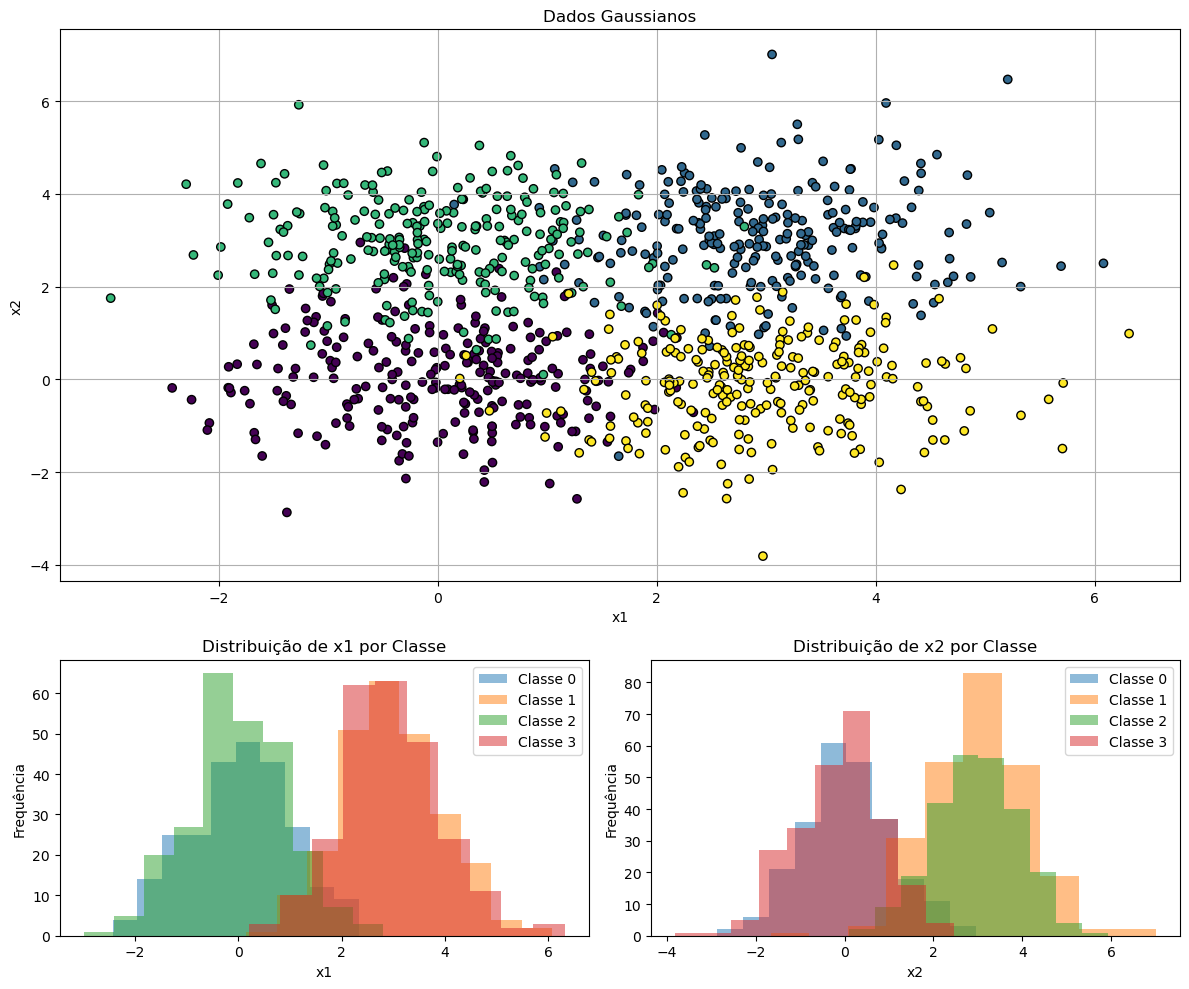

In [6]:
params = {
    "n_classes": 4,
    "n_samples": 1000,
    "means": [[0, 0], [3, 3], [0, 3], [3, 0]],
    "covs": [np.eye(2), np.eye(2), np.eye(2), np.eye(2)],
    "priors": [0.25, 0.25, 0.25, 0.25],
    "seed": 42,
}


data, labels, groups = generate_data(**params)

plot_2D(data, labels)

In [7]:
data, labels, groups = generate_data(**params)

prob = get_proba(data, **params)

pred, confidence = classifier(prob)

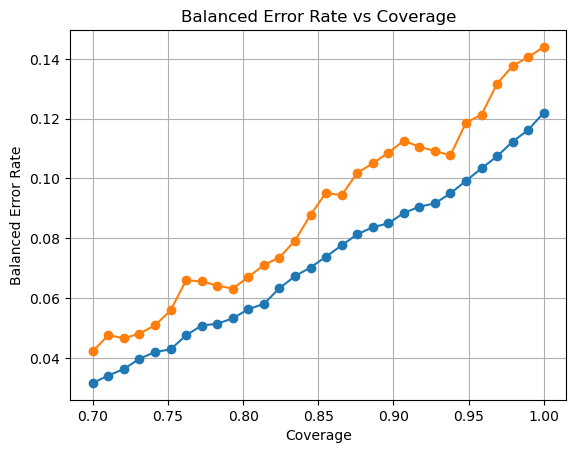

In [8]:
ber_vect = list()
wg_vect = list()

coverages = np.linspace(0.7, 1.0, 30)

for coverage in coverages:
    thr = np.percentile(confidence, (1 - coverage) * 100)
    accept_idx = rejector(confidence, thr)
    ber_vect.append(balanced_error_vect(labels[accept_idx], pred[accept_idx]))
    wg_vect.append(worst_group_error_vect(labels[accept_idx], pred[accept_idx]))

plt.plot(coverages, ber_vect, marker="o")
plt.plot(coverages, wg_vect, marker="o")
plt.xlabel("Coverage")
plt.ylabel("Balanced Error Rate")
plt.title("Balanced Error Rate vs Coverage")
plt.grid()
plt.show()

# Geração e predição


In [9]:
def plot_thresholds(
    data: np.array, labels: np.array, preds: np.array, thresholds: list
) -> None:

    n_plots = len(thresholds) - 1

    fig, ax = plt.subplots(n_plots, figsize=(10, 10))

    for i, threshold in enumerate(thresholds[1:]):
        mask = rejector(confidence, threshold)
        masked_data = data[mask]
        accuracia = 1 - error(labels[mask], preds[mask])
        error_mask = labels[mask] != preds[mask]

        ax[i].scatter(
            masked_data[:, 0],
            masked_data[:, 1],
            c=error_mask,
            cmap="viridis",
            edgecolor="k",
            alpha=0.5,
        )
        ax[i].set_title(
            f"Máscara com {threshold=} - {masked_data.shape[0]} amostras, accuracia={accuracia:.2f}"
        )
        ax[i].grid()

    plt.tight_layout()
    plt.show()

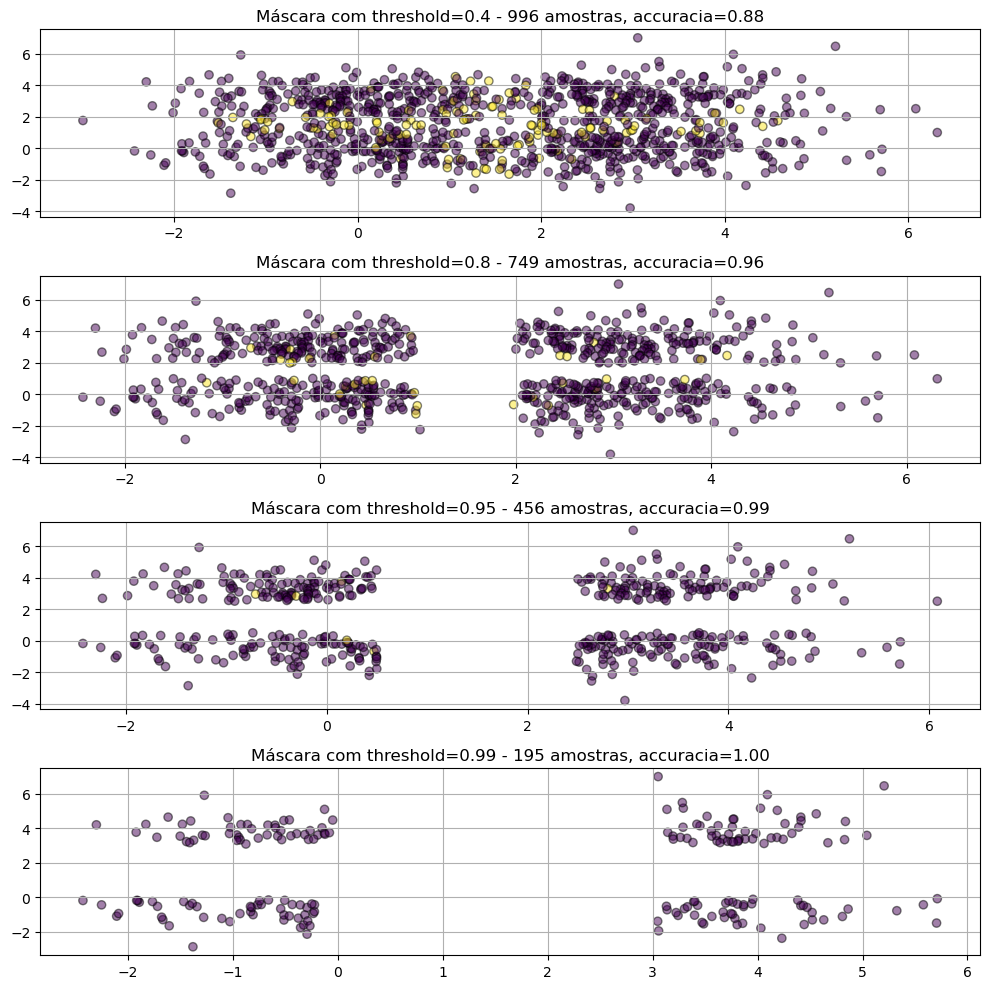

In [10]:
t_tests = [0, 0.4, 0.8, 0.95, 0.99]
plot_thresholds(data, labels, pred, t_tests)